In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [14]:
    
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [15]:
# 1. Load Dataset

df = pd.read_csv("C:/Users/santh/OneDrive - Rathinam Group Of Institutions/Desktop/Dropout Project/university_student_retention_dataset_2134.csv")

print("Dataset Shape:", df.shape)
print(df.info())
print(df.head())

Dataset Shape: (2134, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2134 entries, 0 to 2133
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              2134 non-null   object 
 1   age                     2134 non-null   int64  
 2   gender                  2134 non-null   object 
 3   ethnicity               2134 non-null   object 
 4   major                   2134 non-null   object 
 5   gpa_current             2134 non-null   float64
 6   gpa_history             2134 non-null   float64
 7   attendance_rate         2134 non-null   float64
 8   enrollment_gap_months   2134 non-null   int64  
 9   credits_completed       2134 non-null   int64  
 10  financial_aid_status    2134 non-null   bool   
 11  academic_warning_count  2134 non-null   int64  
 12  advisor_meeting_count   2134 non-null   int64  
 13  advising_notes          2134 non-null   object 
 14  counseling_not


Target Distribution:
next_semester_dropout
False    1773
True      361
Name: count, dtype: int64


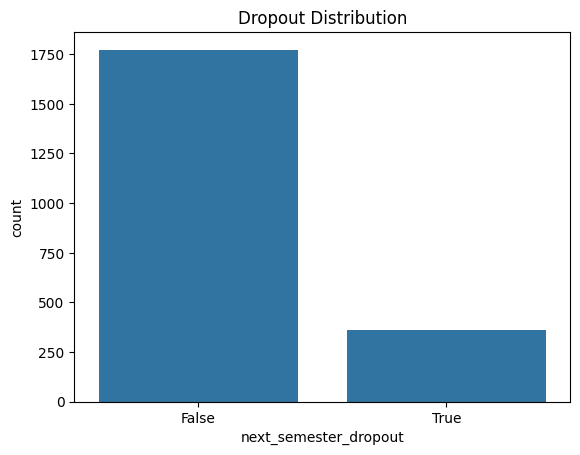

In [16]:
# 2. Basic Data Analysis

print("\nTarget Distribution:")
print(df["next_semester_dropout"].value_counts())

sns.countplot(x="next_semester_dropout", data=df)
plt.title("Dropout Distribution")
plt.show()


In [17]:
# 3. Feature & Target Split

X = df.drop("next_semester_dropout", axis=1)
y = df["next_semester_dropout"]


In [18]:
# 4. Identify Feature Types

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [19]:
# 5. Preprocessing Pipeline


numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [20]:
# 6. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [21]:
# 7. Logistic Regression Model

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Logistic Regression Report
              precision    recall  f1-score   support

       False       1.00      0.86      0.92       355
        True       0.59      1.00      0.74        72

    accuracy                           0.88       427
   macro avg       0.80      0.93      0.83       427
weighted avg       0.93      0.88      0.89       427

ROC AUC: 0.9397496087636933


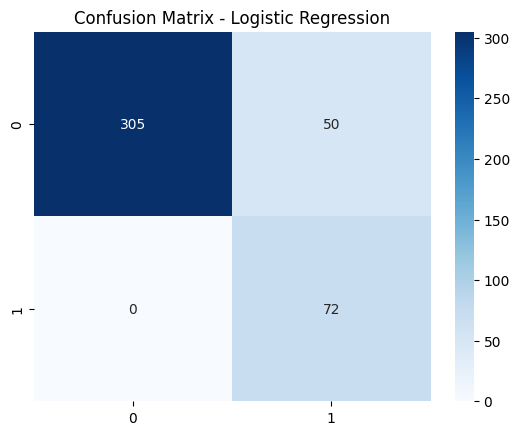

In [22]:
# 8. Logistic Regression Evaluation

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
# 9. Random Forest Model

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Random Forest Report
              precision    recall  f1-score   support

       False       0.99      0.87      0.92       355
        True       0.59      0.94      0.73        72

    accuracy                           0.88       427
   macro avg       0.79      0.91      0.83       427
weighted avg       0.92      0.88      0.89       427

ROC AUC: 0.9333333333333333


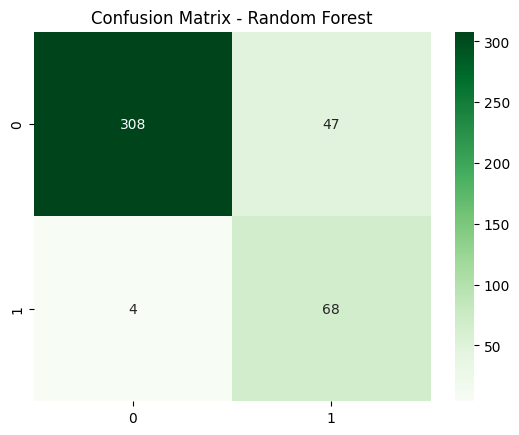

In [24]:
# 10. Random Forest Evaluation


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.show()

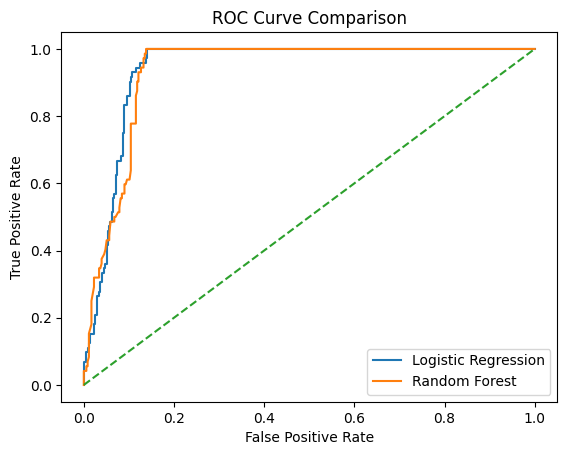

In [25]:
# 11. ROC Curve Comparison


fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [26]:
# 12. Feature Importance (Random Forest)


rf_clf = rf_model.named_steps["classifier"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))


Top 10 Important Features:
                               Feature  Importance
5149             cat__dropout_type_nan    0.163972
5154            cat__dropout_cause_nan    0.157488
8                num__dropout_duration    0.077909
5146       cat__dropout_type_Permanent    0.040077
5148        cat__dropout_type_Transfer    0.031936
5147       cat__dropout_type_Temporary    0.030962
5153          cat__dropout_cause_Other    0.027084
5150       cat__dropout_cause_Academic    0.026910
5152  cat__dropout_cause_Mental Health    0.025373
5151      cat__dropout_cause_Financial    0.024509


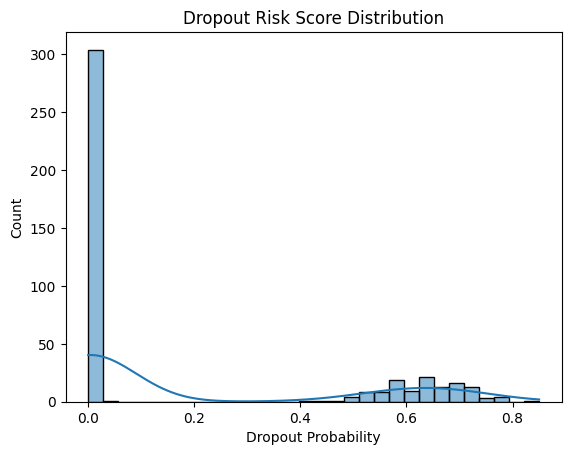

In [27]:
# 13. Risk Score Visualization


risk_scores = y_prob_rf

sns.histplot(risk_scores, bins=30, kde=True)
plt.title("Dropout Risk Score Distribution")
plt.xlabel("Dropout Probability")
plt.show()